# Assignment 3: LLMs and Machine Learning

---

## Submission Instructions

Submit only a link to the folder for Assignment 3 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment3.ipynb` or something similar, placed inside the `assignments/assignment3/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

AI was used to:

- make a final improvement to the prompt in task 1 to keep a count of the previously returned email classifications. 
- consult about the proper preprocessing of the variables for supervised ml task, if label is coding is relevant for certain variables. Also, it was used to troubleshoot the errors while using sklearn Encoders
- consukt about the logic behing using the different ML algorithms given properties of the data and underlying mechanics of the algos. FInalizing the set of the models to be used.
- The set of hyperparameters for the chosen models was randomized with help of AI
- Improve spelling in the markdown cells

## Grading

This assignment is worth 10 points. Task 0 is worth 2 points, and tasks 1-8 are worth 1 point each.

Points are given only for code that runs. If the code does not run, the task will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).
- **-1 point** if there is no statement of AI use. If you did not use AI, report that you did not use AI.

### Editing the submission after the deadline

- Editing the assignment submission during the evaluation phase is forbidden. Thus, after the solution has been released, do not make any further changes to the notebook until you have received a grade. If you accidentally leaked an API key, revoke the key immediately. Other **changes to the submission are considered cheating, and will result in 0 points for both the assignment and peer review**.

---

## Tasks

### Task 0: Setting up Ollama (1p)

a) Set up Ollama and connect to it using either openAI's API or Ollama's own API. 

b) Load the 270m parameter version of the [gemma3](https://ollama.com/library/gemma3) model and test it with any prompt.

c) Load the 4b parameter version of the [gemma3](https://ollama.com/library/gemma3) and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

### a)

In [1]:
from openai import OpenAI

ollama_client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)

### b)

In [2]:
import time 

model = "gemma3:270m"

def ask_ollama(prompt):
    response = ollama_client.chat.completions.create(
        model=model,
        messages=[{"role":"user", "content": prompt}]
    )
    return response.choices[0].message.content

test_prompt = "What is use case of Ollama model gemma3:270m? Answer in one sentence."


start = time.time()
print(ask_ollama(test_prompt))
end = time.time()

print()
model_270m_runtime = end-start
print(f"It took {model_270m_runtime:.4f} seconds to run the ollama gemma3:270m model")


Ollama model gemma3:270m offers a lightweight and efficient way to manage tasks and collaborate on projects using a well-architected, open-source model.


It took 4.4758 seconds to run the ollama gemma3:270m model


### c)

In [3]:
start = time.time()
model = "gemma3:4b"

prompt_4b = "What is the use case of Ollama model gemma3:4b and why it weights so much? Answer shortly please"

print(ask_ollama(prompt_4b))

end = time.time()

print()
model_4b_runtime = end-start
print(f"It took {model_4b_runtime:.4f} seconds to run the ollama gemma3:4b model")

Here’s a short answer to your questions about Ollama’s Gemma 3B:4B model:

*   **Use Case:** Gemma 3B:4B is designed for **local, conversational AI applications**. It's suitable for tasks like chatbots, creative writing, and code generation, running directly on your computer without relying on cloud services.

*   **Why it weights so much:** The "4B" refers to 4 billion parameters – a large number indicating a powerful model with a greater capacity to learn complex patterns in language. This translates to higher quality and more nuanced responses, but also demands more processing power and storage.

It took 18.3953 seconds to run the ollama gemma3:4b model


### Task 1: Text classification with Ollama (2p)

The `data/emails.csv` file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

#### a) 

As this is a CSV file and naturally in sentences there are commas, one needs to specify delimiter other than punctuations signs in the sentences.

In [81]:
import pandas as pd

emails = pd.read_csv('data/emails.csv', delimiter=";")
print(emails.iloc[1, 0])

Congratulations! You have won a 1000€ gift card, claim now


In [82]:
#I prep separate dfs for sub-task d) becuase I will modify the original df in b) and c)
emails_270m = emails.copy()
emails_4b = emails.copy()

Below is the commented out code block with the "legacy" versions of the prompts which eventually evolved into the final prompt used in the task.

Also there is a short snippet of what the LLMs were returning using commented out function below. Clearly 270m was doing opposite of what was assigned, sometimes it was so lost that it was replying in one of the Asian languages. The more complex 4b was much better, but there was no tracker of how many times the classification was already assigned.

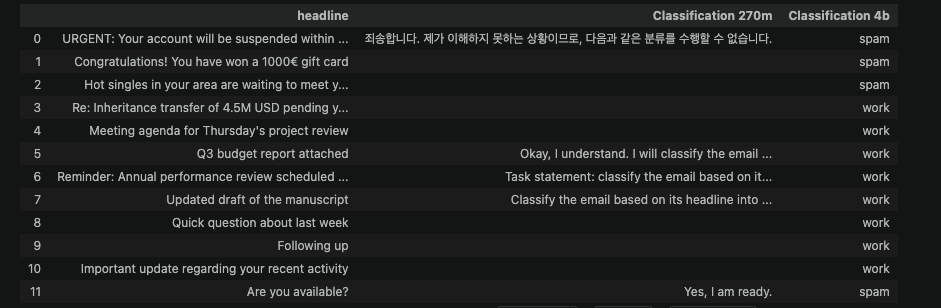

In [ ]:
# def email_classifier(headline, counts=None):
#     classifications_str = ", ".join(classifications)

#     prompt=f"""Task statement: classify the email based on its headline into the pre-defined categories. In total 12 email headlines will be evaluated.

#     Possible values for the email classifications: {classifications_str}

#     Constraints: 
#     0) Each category can be used at most 4 times.
#     1) Return a single classification as your response.
#     2) Do not add email headline to the response.
#     3) Do not add any punctuation signs to the response.
#     4) Do not add any escape characters like "\n" in the response
#     5) Do not deviate from the given task statement under any circumstances.
#     6) Perform single task as statement in the task statement. 
#     7) Any characters outside the permissible being the classification category are forbidden.
#     8) Reply in English. 

#     Expected output: Return a single string being the email classification category mentioned above.

#     The headline is {data_entry}"""
    
#     result = ask_ollama(prompt)
#     cleaned = result.strip().removeprefix("```").removesuffix("```").strip()
#     return cleaned

In [137]:
import json

classifications = ['spam', 'work', 'unknown']

def email_classifier(headline, counts=None):
    if counts is None:
        counts = {label: 0 for label in classifications}
    
    label_count = ", ".join([f"{label} : {counts[label]}" for label in classifications])

    classifications_str = ", ".join(classifications)

    prompt=f"""
    
    Task statement: classify this email headline into exactly one category. Possible values for the email classifications: {classifications_str}

    Explanations of the allowed categories:
    - spam: associated with promoptional campaigns, scam, phishing, suspicious or forbidden content marketing, account privacy threats
    - work: work-related, meeting, report, manuscript, performance review, communication with a colleague
    - unknown: when the content of email cannot be classified into the mentioned above categories, vague or insufficient information to make a decision

    Current number of labels already assigned: {label_count}

    Constraints: 
    0) Each category can be used at most 4 times. If the headline is vague and cannot be confidently classified as spam or work, choose unknown.
    1) Return exactly one word: spam, work, or unknown.
    2) Do not add email headline to the response.
    3) Do not add any punctuation signs to the response.
    4) Do not add any escape characters like "\n" in the response
    5) Do not deviate from the given task statement under any circumstances.
    6) Perform single task as statement in the task statement. 
    7) Any characters outside the permissible being the classification category are forbidden.
    8) Reply in English. 

    Expected output: Return a single string being the email classification category mentioned above.

    The headline is {headline}"""
    
    result = ask_ollama(prompt)
    cleaned = result.strip().removeprefix("```").removesuffix("```").strip()
    return cleaned

#### b)

In [84]:
model = "gemma3:270m"
emails["Classification 270m"] = emails["headline"].apply(email_classifier)
emails

,headline,Classification 270m
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,unknown
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,unknown
5,"Q3 budget report attached, please review by Fr...",unknown
6,Reminder: Annual performance review scheduled ...,unknown
7,"Updated draft of the manuscript, comments welcome",describes a spam email.
8,Quick question about last week,spam
9,Following up,spam


#### c)

In [85]:
model = "gemma3:4b"

emails["Classification 4b"] = emails['headline'].apply(email_classifier)

emails

,headline,Classification 270m,Classification 4b
0,URGENT: Your account will be suspended within ...,spam,spam
1,Congratulations! You have won a 1000€ gift car...,unknown,spam
2,Hot singles in your area are waiting to meet y...,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,work
4,Meeting agenda for Thursday's project review,unknown,work
5,"Q3 budget report attached, please review by Fr...",unknown,work
6,Reminder: Annual performance review scheduled ...,unknown,work
7,"Updated draft of the manuscript, comments welcome",describes a spam email.,work
8,Quick question about last week,spam,unknown
9,Following up,spam,unknown


#### d)

In [86]:
for i in range (1,4):
    model = "gemma3:270m"
    emails_270m[f'270m_{i}'] = emails['headline'].apply(email_classifier)

display(emails_270m)

,headline,270m_1,270m_2,270m_3
0,URGENT: Your account will be suspended within ...,spam,spam,unknown
1,Congratulations! You have won a 1000€ gift car...,unknown,spam,spam
2,Hot singles in your area are waiting to meet y...,unknown,spam,8
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,unknown,spam
4,Meeting agenda for Thursday's project review,unknown,unknown,unknown
5,"Q3 budget report attached, please review by Fr...",spam,spam,unknown
6,Reminder: Annual performance review scheduled ...,spam,spam,unspecified
7,"Updated draft of the manuscript, comments welcome",,spam,
8,Quick question about last week,spam,spam,unknown
9,Following up,spam,unknown,spam


In [87]:
for i in range (1,4):
    model = "gemma3:4b"
    emails_4b[f'4b_{i}'] = emails['headline'].apply(email_classifier)

display(emails_4b)

,headline,4b_1,4b_2,4b_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,work,work,work
4,Meeting agenda for Thursday's project review,work,work,work
5,"Q3 budget report attached, please review by Fr...",work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,work,work
8,Quick question about last week,unknown,unknown,unknown
9,Following up,unknown,unknown,unknown


##### Result analysis

Clearly the final, long, polished prompt "guardrails" the models to behave exactly like one expects to. The smaller model 270m needs a higher level of constraint granularity, while 4b was performing already well at the early stages of the prompt development. As the 270m is not that sophisticated, it explains why explicit navigations are needed.

**About the results:** 270m despite good improvement still returns hallucinations like digits, empty responses or random words despite the set instructions. The classifications themselves are neither stable through repetitive iterations. Only the following indices of the df were classified by 270m repetitively: [4, 11] meaning only around 15% reliability if one may say so.

In contrast, 4b model returned close to 100% same result the repetitive trial (despite the classification of index 11 in trial 2). This signifies that model is much more reliable thanks to its complicated structure, featues and supposedely the amount of training data used before model deployment. As model is more sophisticated, it could apparently digest more complex information which gives it advantage in ambiguous headline classification task. 

**All in all**, 4b is much better, but still it returned only 2 unknown classifications, while I would personally classify indices [10, 11] as unknown, rather than spam. It also made a mistake in case of index 3 to classify it as work, while spam would be the correct one. 

### Task 2: Sentiment analysis with Ollama (2p)

The `data/news.csv` file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

In [130]:
news = pd.read_csv("data/news.csv", delimiter=";")
news

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


In [ ]:
# print(news.loc[0, "headline"])
# print(news.iloc[0,0])

Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%
Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%


#### a)

In [113]:
import json
topics = ["earnings", "mergers", "regulation", "macroeconomics"]
sentiment = ["positive", "negative", "neutral"]

def classify_text(text):

    prompt = f"""

    Classify the following news headline.
    Return a JSON object with two keys:
    - "topic": one of the {topics}
    - "sentiment": of the {sentiment}

    Constraints: 
    0) Return only the requested JSON object
    1) Return exactly one word for "topic" key of returned JSON object 
    2) Return exactly one word for "sentiment" classification
    3) Do not add the analyzed text into the response
    4) Do not add any punctuation signs to the response.
    5) Do not add any escape characters like "\n" in the response
    6) Do not include any other text, markdown formatting or code blocks
    7) Any characters outside the permissible being the classification category are forbidden.
    8) Reply in English. 

    The news is {text}"""

    result = ask_ollama(prompt)
    cleaned = result.strip().removeprefix("```json").removeprefix("```").removesuffix("```").strip()
    return json.loads(cleaned)


In [114]:
model="gemma3:4b"

test = classify_text(news.loc[0])

print(json.dumps(test,indent=2))

{
  "topic": "earnings",
  "sentiment": "positive"
}


#### b)

In [ ]:
news_4b = news.copy()

analytics = news_4b["headline"].apply(classify_text)

#print(analytics)

0      {'topic': 'earnings', 'sentiment': 'positive'}
1      {'topic': 'earnings', 'sentiment': 'negative'}
2      {'topic': 'earnings', 'sentiment': 'positive'}
3        {'topic': 'mergers', 'sentiment': 'neutral'}
4    {'topic': 'regulation', 'sentiment': 'negative'}
5        {'topic': 'mergers', 'sentiment': 'neutral'}
6    {'topic': 'regulation', 'sentiment': 'negative'}
7     {'topic': 'regulation', 'sentiment': 'neutral'}
8      {'topic': 'earnings', 'sentiment': 'positive'}
9    {'topic': 'regulation', 'sentiment': 'negative'}
Name: headline, dtype: object


In [110]:
news_4b["Topic"] = analytics.apply(lambda d: d.get('topic', ""))
news_4b["Sentiment"] = analytics.apply(lambda d: d.get('sentiment', ""))

news_4b

,headline,Topic,Sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",earnings,positive
9,Rising interest rates weigh on Tessaro Real Es...,regulation,negative


#### c)

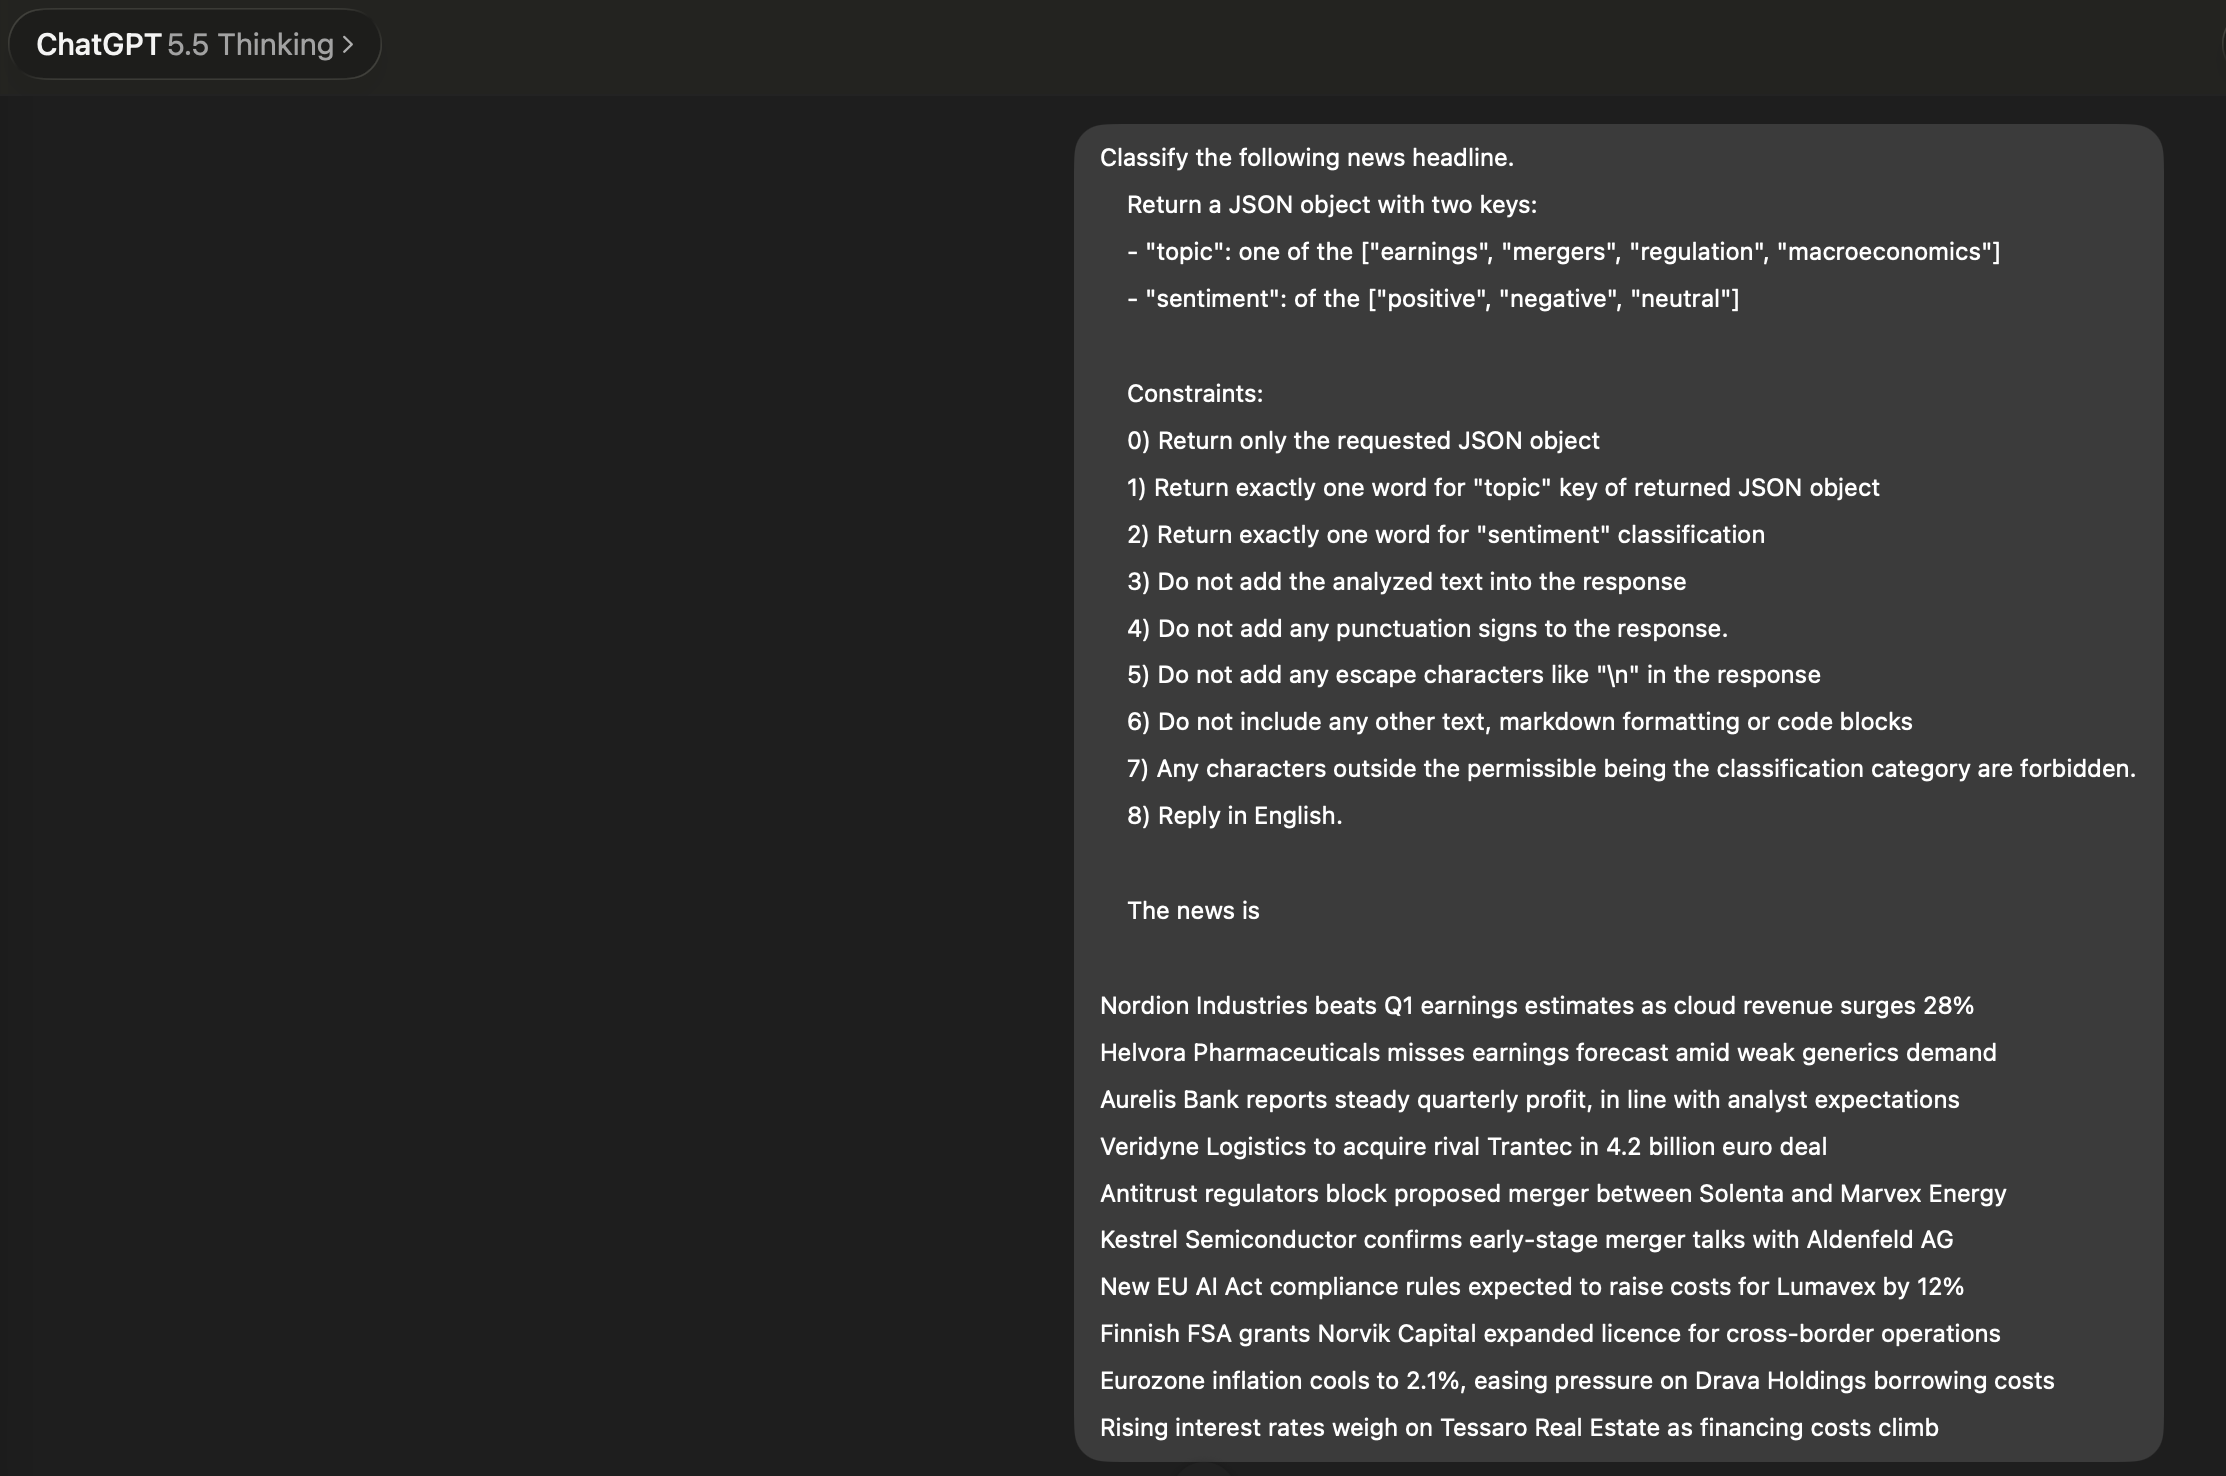

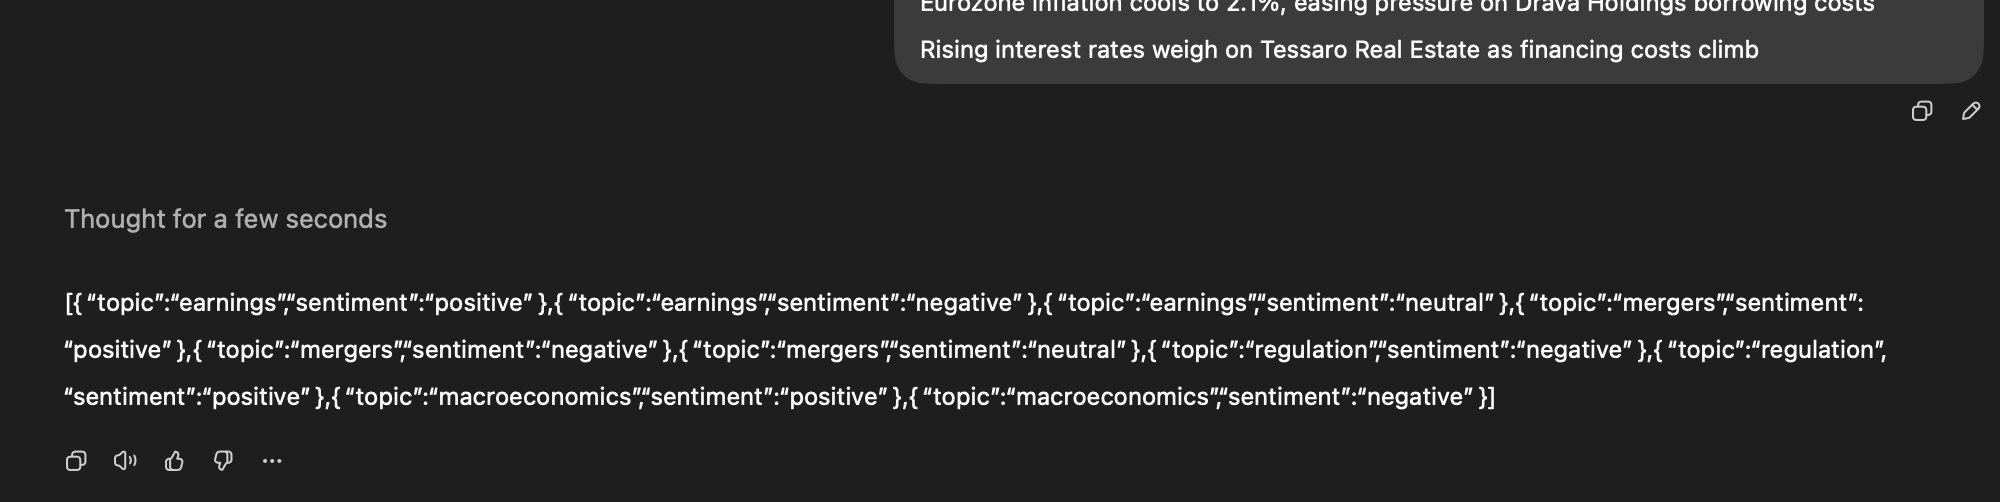

In [131]:
news_chatgpt = news.copy()

gpt_classification = [{"topic": "earnings","sentiment":"positive"},
    {"topic":"earnings","sentiment":"negative"},
    {"topic":"earnings","sentiment":"neutral"},
    {"topic":"mergers","sentiment":"positive"},
    {"topic":"mergers","sentiment":"negative"},
    {"topic":"mergers","sentiment":"neutral"},
    {"topic":"regulation","sentiment":"negative"},
    {"topic":"regulation","sentiment":"positive"},
    {"topic":"macroeconomics","sentiment":"positive"},
    {"topic":"macroeconomics","sentiment":"negative"}]    



In [ ]:
news_chatgpt['Topic'] =  [i['topic'] for i in gpt_classification]
news_chatgpt['Sentiment'] = [i['sentiment'] for i in gpt_classification]

display(news_chatgpt.rename(columns={"Topic": "Topic_GPT", "Sentiment": "Sentiment_GPT"}))
display(news_4b.rename(columns={"Topic": "Topic_4b", "Sentiment": "Sentiment_4b"}))

,headline,Topic_GPT,Sentiment_GPT
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,neutral
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,mergers,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


,headline,Topic_4b,Sentiment_4b
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",earnings,positive
9,Rising interest rates weigh on Tessaro Real Es...,regulation,negative


First of all, to compare both models - **Chat GPT 5.5 Thinking** VS **Ollama Gemma3:4B** I first list how I would classify the news headlines myself:

0. Earnings, positive
1. Earnings, negative
2. Earnings, positive
3. Mergers, neutral (could be also positive)
4. Mergers, neutral (Gemma made a mistake for topic)
5. Mergers, neutral
6. Regulation, negative
7. Regulation, positive
8. Macroeconomics, positive (Gemma made a mistake for topic)
9. Macroeconomics, negative (Gemma made a mistake for topic)

**Chat GPT:s** classification is pretty much in line with mine, despite it classified the *headiline 4* with word "Antitrust" as negative merger topic. I also decided that the *headline 2* with steady profits is worth being classified as positive, despite Chat GPT classified it as neutral, likely because "matching analyst expectations". I initially classified the *headline 3* as neutral, but it also makes sense to make it positive.

**Gemma3:4b** classified *headline 2* as I did. The *headline 3* got classified as neutral, which I also had an idea to classify, but it also makes sense to classify both positive and neutral, because for beneficiary it is of course positive while for rest it is neutral. It made a mistake to classify *headline 4* as regulation instead of merger, supposedly because of the word regulator. For *headline 7* one may also argue that it is neutral rather than positive, so I wouldn't consider it as a mistake either. 
Last two *headlines 8 and 9* should be clearly classified as macro.

**All in all** *Gemma3:4b* made 3 mistakes to misclassify the topic. Chat GPT is more accurate. The minor deviation regarding classification of positive/neutral in couple of cases are a bit ambiguous in my opinion. 

Not bad for the local LLM.

### Task 3: Supervised machine learning (5p)

For this task, use a subset of the [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, by downloading and importing the `bank-additional.csv` from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

#### a)

In [47]:
bank = pd.read_csv('data/bank-additional.csv', delimiter=";")

bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


##### Shape and basic info

In [48]:
print(f"The shape of the df is {bank.shape}")
bank.info()

The shape of the df is (4119, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17 

##### Missing values summary

In [49]:
print("Missing value summary:")
print(bank.isna().sum())

Missing value summary:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


##### Inspecting the non-numeric variables (categorical, binary) to identify the proper encodings 

In [50]:
categorical_cols = bank.select_dtypes(exclude="number").columns

for col in categorical_cols:
    print(f"Inspected column: {col}")
    print(bank[col].value_counts(dropna=False))
    print()

Inspected column: job
job
admin.           1012
blue-collar       884
technician        691
services          393
management        324
retired           166
self-employed     159
entrepreneur      148
unemployed        111
housemaid         110
student            82
unknown            39
Name: count, dtype: int64

Inspected column: marital
marital
married     2509
single      1153
divorced     446
unknown       11
Name: count, dtype: int64

Inspected column: education
education
university.degree      1264
high.school             921
basic.9y                574
professional.course     535
basic.4y                429
basic.6y                228
unknown                 167
illiterate                1
Name: count, dtype: int64

Inspected column: default
default
no         3315
unknown     803
yes           1
Name: count, dtype: int64

Inspected column: housing
housing
yes        2175
no         1839
unknown     105
Name: count, dtype: int64

Inspected column: loan
loan
no         3349
yes

##### Descriptive stats table for numeric values

In [51]:
bank.select_dtypes(include="number").describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


##### Separate table of means

In [52]:
bank.groupby("y").mean(numeric_only=True)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
y,,,,,,,,,,
no,39.895311,219.40976,2.605780,982.763086,0.141767,0.240185,93.599677,-40.586723,3.802826,5175.502072
yes,41.889135,560.78714,1.980044,778.722838,0.585366,-1.177384,93.417268,-39.786475,2.145448,5093.118625


##### Plots

The bar plot below shows the reason why it is critical to remove the variable of duration from the predictives set, as clearly there is a huge spike of value for those who have the term deposit already.

Text(0.5, 0, 'Holding term deposit?')

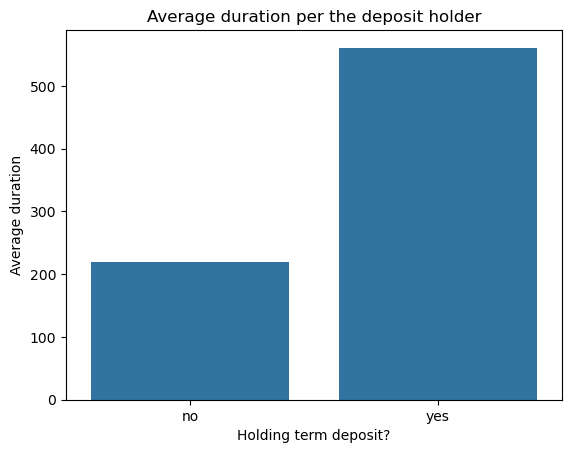

In [53]:
duration_average = bank.groupby("y")['duration'].mean()

sns.barplot(x=duration_average.index, y=duration_average.values)
plt.title('Average duration per the deposit holder')
plt.ylabel('Average duration')
plt.xlabel('Holding term deposit?')

The histogram plots below actually reveal interesting observations about the data. 


First of all, **pdays** being the number of days that passed by after the client was last contacted from a previous campaign - shows that for those who have the term deposit, only minor fraction have agreed for the depost right away. The rest are apparently those who already have deposit, as 1000 days have surpassed since last contact.

Secondly, the **campaign** - number of contacts performed during this campaign and for this client - reveals that highest count of those who have the term deposit have not been contacted only once. The distributional count decreases steadily when number of calls grows.

Finally, **previous** - number of contacts performed before this campaign and for this client - shows the similar patter as campaign. Most successful clients had previous 0, meaning no contacts before this campaign, and the frequency decreases as prior contacts increase.

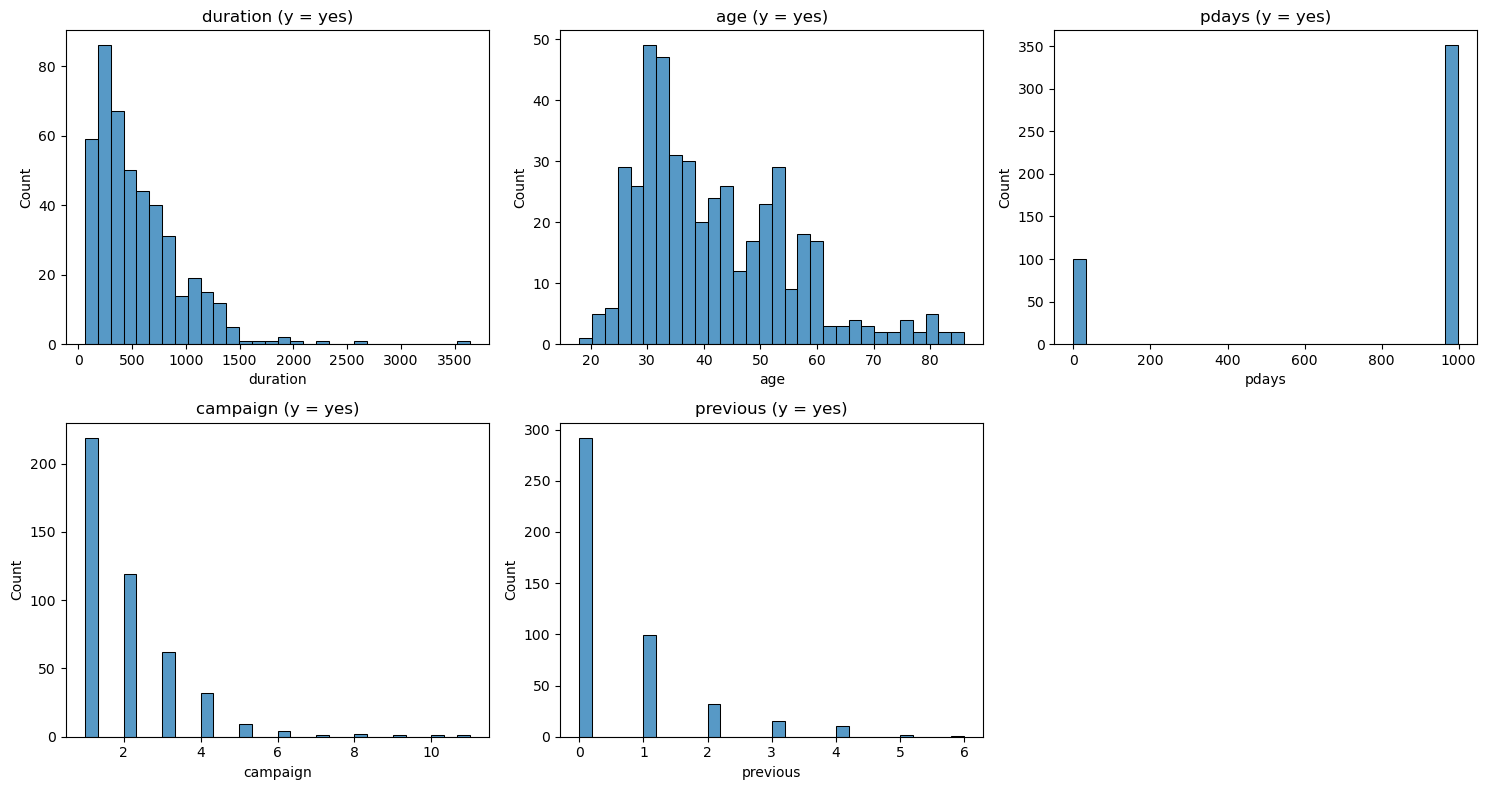

In [54]:
cols = ["duration","age", "pdays", "campaign","previous"]
bank_yes = bank[bank['y'] == 'yes']

fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()  #flatten the grid from 2x3 to 1x6 for the loop

for ax, col in zip(axes, cols):
    sns.histplot(bank_yes[col], bins=30, ax=ax)
    ax.set_title(f"{col} (y = yes)")

axes[-1].set_visible(False) #hide the last plot
plt.tight_layout()
plt.show()

#### b)

After consulting with Sippo, I decided to prepare two versions of the dataset used for the ML task. However, certain transformation are dataset version agnostic:

1. The variable "duration" is removed because it is only known after the call is completed and is therefore not available at prediction time. It also strongly leaks information about the outcome (longer calls are highly correlated with subscription), making the model unrealistic. Plot above supports this statement. It is recommended to use this only as a benchmark. Hence this varible is removed. 
    Moreover, I remove the non-described variables: `[emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed]`. 


2. In addition to that, I apply standardization to the following numeric variables to both datasets: `['age','campaign','pdays', 'previous']`. Standardization is applied to numeric variables to ensure they are on comparable scales. This is important for distance-based models. StandardScaler is preferred over MinMaxScaler because the data contains outliers and skewed distributions as it is visible on the plots, and MinMax scaling would compress most observations into a narrow range. 

    It is by the way safe to apply the standard scaler to `pdays` despite the dataset description says it has -1 value identifying that client was never contacted.
3. I also convert the target variable `y`to the binary outcome. Also, the binary encoding as applied to variable `contact`

4. The Education variable is re-mapped using *Ordered Labling*, as there is clearly a hierarchy of educational levels.

5. Variable `marital`is cleaned by replacing values *unknown* with NAs and these missing values are removed. Rest three categories are transformed using dummy encoding as in the exercise materials.

In [55]:
bank['pdays'].value_counts()

pdays
999    3959
3        52
6        42
4        14
7        10
10        8
12        5
5         4
2         4
1         3
9         3
16        2
13        2
18        2
0         2
15        2
19        1
17        1
11        1
21        1
14        1
Name: count, dtype: int64

##### b.1. Standalone transformations

In [56]:
# 1. Drop bias and unknown columns
bank_ml = bank.drop(columns=['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'])

In [57]:
# 2. Standard scaler 
from sklearn.preprocessing import StandardScaler
scaler_standard = StandardScaler()
bank_ml[['age','campaign','pdays', 'previous']] = scaler_standard.fit_transform(bank_ml[['age','campaign','pdays', 'previous']])

In [58]:
# 3. Binary outcome coding to target variable y and contact
bank_ml['y'] = bank_ml['y'].map({'yes': 1, 'no': 0})

bank_ml['contact'] = bank_ml['contact'].map({"cellular": 1,"telephone": 0})

In [59]:
# 4. Ordinal encoder of Education
education_order = ["unknown",
    "illiterate",
    "basic.4y",
    "basic.6y",
    "basic.9y",
    "high.school",
    "professional.course",
    "university.degree"
]

from sklearn.preprocessing import OrdinalEncoder
edu = OrdinalEncoder(categories=[education_order])

bank_ml['education'] = edu.fit_transform(bank_ml[['education']])

In [60]:
# 5. Marital Dummy encoding and dropping "unknown" (just 11 values, no big deal)

bank_ml['marital'] = bank_ml['marital'].replace('unknown', pd.NA, regex=False)
bank_ml = bank_ml.dropna()

bank_ml = pd.get_dummies(bank_ml, columns=['marital'], dtype=float)

bank_ml.head(5)

,age,job,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,y,marital_divorced,marital_married,marital_single
0,-0.980752,blue-collar,4.0,no,yes,no,1,may,fri,-0.209228,0.201031,-0.351356,nonexistent,0,0.0,1.0,0.0
1,-0.107991,services,5.0,no,no,no,0,may,fri,0.569634,0.201031,-0.351356,nonexistent,0,0.0,0.0,1.0
2,-1.465619,services,5.0,no,yes,no,0,jun,wed,-0.598660,0.201031,-0.351356,nonexistent,0,0.0,1.0,0.0
3,-0.204965,services,4.0,no,unknown,unknown,0,jun,fri,0.180203,0.201031,-0.351356,nonexistent,0,0.0,1.0,0.0
4,0.667795,admin.,7.0,no,yes,no,1,nov,mon,-0.598660,0.201031,-0.351356,nonexistent,0,0.0,1.0,0.0


Then I create a copy of the dataset, `bank_ml`, and perform separate transformations. The rationale for this is the following.

For instance, the variables `['default', 'housing', 'loan']` contain the value **"unknown"** in addition to "yes" and "no". Ideally, these unknown observations would be removed or replaced to enable binary encoding. However, this would result in the loss of approximately 800 observations, which is a substantial portion of the dataset. An alternative approach would be to apply label encoding to retain all observations.

Furthermore, the variables `['day_of_week', 'month', 'poutcome', 'job']` may appear suitable for label encoding. However, this approach introduces an artificial ordering in inherently nominal variables. For example, the model may incorrectly infer that Saturday is “greater” than Friday, which leads to biased interpretations. While one-hot encoding avoids this issue, it significantly increases the dimensionality of the dataset. Therefore, potential approaches include either removing these variables or applying label encoding followed by standardization to mitigate the impact of artificial ordering.

Based on these considerations, I define two separate datasets with distinct preprocessing strategies:

- bank_ml1
    - The variables `['default', 'housing', 'loan']` are transformed using label-like encoding. These variables are retained because they carry meaningful information about the financial condition of the client. For example, having a housing loan or prior default may influence the likelihood of subscribing to a term deposit. 
    
    - The variables `['day_of_week', 'month', 'poutcome', 'job']` are transformed using label encoding. No standardization applied, as I am eager to see how well logictics regression would perform when the variables like that are non-standardized and opposite. 

- bank_ml2
    - All rows containing "unknown" values in `['default', 'housing', 'loan']` are removed. Although this reduces the dataset size, it allows for clean binary encoding of these variables.
    - The variables `['day_of_week', 'month']` are removed entirely, as they are less informative and problematic to encode appropriately
    - The variables `['poutcome', 'job']` are transformed using label encoding, followed by standardization.



In [61]:
bank_ml1 = bank_ml.copy()
bank_ml2 = bank_ml.copy()

##### b.2.1. bank_ml1 Variation


In [62]:
# label encoding for default, housing, loan
label_map = {"no": 0, "yes": 1, "unknown": -1}

for col in ["default", "housing", "loan"]:
    bank_ml1[col] = bank_ml1[col].map(label_map)

In [63]:
# Common label encoder on the variables below
from sklearn.preprocessing import LabelEncoder

le_cols = ["job", "poutcome", "month", "day_of_week"]

for col in le_cols:
    le = LabelEncoder()
    bank_ml1[col] = le.fit_transform(bank_ml1[col])

In [64]:
bank_ml1.head()

,age,job,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,y,marital_divorced,marital_married,marital_single
0,-0.980752,1,4.0,0,1,0,1,6,0,-0.209228,0.201031,-0.351356,1,0,0.0,1.0,0.0
1,-0.107991,7,5.0,0,0,0,0,6,0,0.569634,0.201031,-0.351356,1,0,0.0,0.0,1.0
2,-1.465619,7,5.0,0,1,0,0,4,4,-0.598660,0.201031,-0.351356,1,0,0.0,1.0,0.0
3,-0.204965,7,4.0,0,-1,-1,0,4,0,0.180203,0.201031,-0.351356,1,0,0.0,1.0,0.0
4,0.667795,0,7.0,0,1,0,1,7,1,-0.598660,0.201031,-0.351356,1,0,0.0,1.0,0.0


##### b.2.2. bank_ml2 Variation

In [65]:
# Replace unknown with NAs and remove these values

for col in ["default", "housing", "loan"]:
    bank_ml2[col] = bank_ml2[col].replace("unknown", pd.NA)

bank_ml2 = bank_ml2.dropna(axis=0, how="any")

In [66]:
# Then map cleaned variables to binary outcome
binary_map= {"no": 0, "yes": 1}

for col in ["default", "housing", "loan"]:
    bank_ml2[col] = bank_ml2[col].map(binary_map)

In [67]:
# Drop days and months columns
bank_ml2 = bank_ml2.drop(columns=["day_of_week", "month"])

In [68]:
# Label encoding on job and poutcome, then standardization
le_cols_2 = ["job", "poutcome"]

for col in le_cols_2:
    le = LabelEncoder()
    bank_ml2[col] = le.fit_transform(bank_ml2[col])

scaler = StandardScaler()
bank_ml2[le_cols_2] = scaler.fit_transform(bank_ml2[le_cols_2])

In [69]:
bank_ml2.head()

,age,job,education,default,housing,loan,contact,campaign,pdays,previous,poutcome,y,marital_divorced,marital_married,marital_single
0,-0.980752,-0.790076,4.0,0,1,0,1,-0.209228,0.201031,-0.351356,0.190361,0,0.0,1.0,0.0
1,-0.107991,0.853615,5.0,0,0,0,0,0.569634,0.201031,-0.351356,0.190361,0,0.0,0.0,1.0
2,-1.465619,0.853615,5.0,0,1,0,0,-0.598660,0.201031,-0.351356,0.190361,0,0.0,1.0,0.0
4,0.667795,-1.064024,7.0,0,1,0,1,-0.598660,0.201031,-0.351356,0.190361,0,0.0,1.0,0.0
5,-0.786805,0.853615,7.0,0,0,0,1,0.180203,0.201031,3.340571,-2.357002,0,0.0,0.0,1.0


#### c)

This is clearly classification problem as in any case the target variable `y` has the binary outcome: either yes or no. Morevoer, we can apply only supervised machine learning algorithms as we essentially look to predict the outcome of the target label `y`. 

I will apply the following supervised ML classification algorithms:

- **Classification tree** - highly intuitive in the interpretation. We may grow the tree given the set of the features and literally track how many positive/negative labels are distributed across the leaves of the tree. 

- **Random forests** - known to be the better alternative to classification trees - as it fits many overfitted trees and averages over the predicted values to get more balanced outcome. It uses bootstrapping with replacement as the underlying mechanism, which helps to mitigate the issue with the smaller dataset. THis might be especially helpful like in case when we remove `unknown observations`for important variables like `loan, default and housing`. Moreover, as we have quite a variety of the variables in this case, random subsets of the variable may reveal us which actually matter. 

- **Logistics regression** - I have a hunch that there might be a linear relationship between education, if one has the loan or mortgage already, age and job occupation to have a direct impact on the desire of the candidate to agree on the term deposit. Regression is in general considered to be the benchmark model in many cases, and logistics regression suits our classification task. 


Given this setup, I expect that `bank_ml1` is better suited for tree-based methods, as these models are not sensitive to feature scaling and can handle encoded categorical variables more flexibly. In contrast, the applied encoding may introduce distortions for **logistic regression**, which assumes meaningful numerical relationships between features.

I am also interested in evaluating whether the reduction in dataset of `bank_ml2` size, caused by removing observations with "unknown" values in key variables such as `default, housing, and loan` can be mitigated by **bootstrap-based methods like random forests**, which are generally robust to smaller samples.

Furthermore, in `bank_ml2`, I remove potentially noisy variables such as **day_of_week and month**, as they are unlikely to significantly influence the subscription decision. I also apply standardization to label-encoded variables such as poutcome and job to assess whether logistic regression performance improves under this transformation.

#### c.1 - Train - validation - test splits to both dataset variations

In [70]:
from sklearn.model_selection import train_test_split
rand_state = 100
y_ml1 = bank_ml1['y']
X_ml1 = bank_ml1.drop(columns=['y'])

y_ml2 = bank_ml2['y']
X_ml2 = bank_ml2.drop(columns=['y'])

# 60-20-20: Train-validation-test set for ml1
X_ml1_temp, X_ml1_test, y_ml1_temp, y_ml1_test = train_test_split(X_ml1, y_ml1, test_size=0.2, random_state=rand_state)
X_ml1_train, X_ml1_val, y_ml1_train, y_ml1_val = train_test_split(X_ml1_temp, y_ml1_temp, test_size=0.25, random_state=rand_state)

# 60-20-20: Train-validation-test set for ml2
X_ml2_temp, X_ml2_test, y_ml2_temp, y_ml2_test = train_test_split(X_ml2, y_ml2, test_size=0.2, random_state = rand_state)
X_ml2_train, X_ml2_val, y_ml2_train, y_ml2_val = train_test_split(X_ml2_temp, y_ml2_temp, test_size=0.25, random_state = rand_state)

print("Train set size for ml1:", X_ml1_train.shape[0]); print("Train set size for ml2:", X_ml2_train.shape[0])
print()
print("Validation set size for ml1:", X_ml1_val.shape[0]); print("Validation set size for ml2:", X_ml2_val.shape[0])
print()
print("Test set size for ml1:", X_ml1_test.shape[0]); print("Test set size for ml2:", X_ml2_test.shape[0])

Train set size for ml1: 2464
Train set size for ml2: 1935

Validation set size for ml1: 822
Validation set size for ml2: 645

Test set size for ml1: 822
Test set size for ml2: 645


In [71]:
print("Target label balance for ml1:")
pd.crosstab(bank_ml1['y'],bank_ml1['y'], normalize='all').reset_index(drop=True)

Target label balance for ml1:


y,0,1
0,0.890458,0.000000
1,0.000000,0.109542


In [72]:
print("Target label balance for ml2:")
pd.crosstab(bank_ml2['y'],bank_ml2['y'], normalize='all').reset_index(drop=True)

Target label balance for ml2:


y,0,1
0,0.87814,0.00000
1,0.00000,0.12186


##### c.2. Setting up the hyperparameters for the chosen models

In [73]:
class_tree_param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None], #max depth of the nodes per tree
    "min_samples_split": [2, 5, 10, 20, 50], #minimum number of observations to split to the node
    "ccp_alpha": [0.0, 0.0001, 0.001, 0.01, 0.05] #complexity parameter, smth like regularization parameter in Lasso/Ridge
}

In [74]:
rf_param_grid = {
    "n_estimators": [100, 200, 500, 800], #number of fitted trees
    "min_samples_leaf": [1, 2, 5, 10, 20], #minimum number of observations per each leaf
    "max_leaf_nodes": [None, 10, 20, 50, 100], #maximum number of leaves per each tree
    "max_depth": [None, 5, 10, 20] #number of main splits allowed per tree
}

In [75]:
logit_param_grid = {
    "penalty": ['l1', 'l2'],
    "C": [0.001, 0.01, 0.1, 1, 10, 100], #regularization strength, complexity parameter
    "solver": ["liblinear"]
}

#### c.3.1 Training and validating models manually - data variation 1

After asking Sippo, I figured out that we should do the manual adjustment of the parameters in the part c) using the train-val-test splits. This means that for every combination one supposedly should train on train, validate on validate and lock in the final result on test. 

It would produce too much output if I output the confusion matrix and all the assessment metrics for both validate and test results. I limit the parameter setup up to 3 combinations and I still have 2 datasets to test. The result grid would explode so instead I will aggregate the most important metrics into the df, while the final best model from validation will be tested on test and then result will be appended to the same df alongside the confusion matrix display.

If one wants, they can uncomment the code in the for loops to output the confusion matrix after each train-validate cycle per model.

I will repeat the same approach -  identical code and output - but for data set 2

In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import ParameterSampler
from scipy.stats import randint


##### c.3.1.1. Classification tree

In [77]:
## Classification tree

# Take the random sample of the parameters I coded above using the ParameterSampler method from sklearn
random_params_ct = list(ParameterSampler(class_tree_param_grid,n_iter=3, random_state=rand_state))

results = []
# Do a loop through the parameter sample
for params in random_params_ct:

    # Define the model
    ct_model = DecisionTreeClassifier(**params, random_state=rand_state, class_weight="balanced")

    # Fit the model to the training set 
    ct_model.fit(X_ml1_train, y_ml1_train)

    # Predict using validation set and report Recall at validation stage
    y_pred_ct = ct_model.predict(X_ml1_val)

    # print(f"--- Classification tree {params} ---")
    # cm = confusion_matrix(y_ml1_val, y_pred_ct)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    # disp.plot()
    # disp.ax_.set_title(f"{params} Val Confusion Matrix")
    # plt.tight_layout()
    # plt.show()

    results.append({
        "Stage": "Val",
         "Params": params,
         "Recall": round(recall_score(y_ml1_val, y_pred_ct),3),
         "Accuracy": round(accuracy_score(y_ml1_val, y_pred_ct),3),
         "Precision": round(precision_score(y_ml1_val, y_pred_ct),3),
         "F1": round(f1_score(y_ml1_val, y_pred_ct),3)

    })


results1_ct = pd.DataFrame(results).sort_values("Recall", ascending=False).reset_index(drop=True)
display(results1_ct)


,Stage,Params,Recall,Accuracy,Precision,F1
0,Val,"{'min_samples_split': 50, 'max_depth': 5, 'ccp...",0.890,0.471,0.160,0.271
1,Val,"{'min_samples_split': 5, 'max_depth': 3, 'ccp_...",0.879,0.428,0.148,0.254
2,Val,"{'min_samples_split': 50, 'max_depth': 6, 'ccp...",0.835,0.541,0.174,0.287


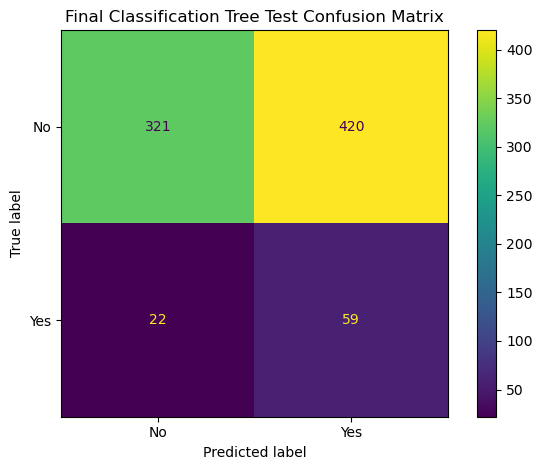

,Stage,Params,Recall,Accuracy,Precision,F1
0,Best test,"{'min_samples_split': 50, 'max_depth': 5, 'ccp...",0.728,0.462,0.123,0.211
1,Val,"{'min_samples_split': 50, 'max_depth': 5, 'ccp...",0.890,0.471,0.160,0.271
2,Val,"{'min_samples_split': 5, 'max_depth': 3, 'ccp_...",0.879,0.428,0.148,0.254
3,Val,"{'min_samples_split': 50, 'max_depth': 6, 'ccp...",0.835,0.541,0.174,0.287


In [78]:
#choose the best result parameters based on Recall metric output
best_params = results1_ct.iloc[0]["Params"]
best_params

# fit the best model to the training set
ct_final = DecisionTreeClassifier(**best_params,random_state=rand_state,class_weight="balanced")
ct_final.fit(X_ml1_train, y_ml1_train)

#Final prediction on test
y_pred_ct = ct_final.predict(X_ml1_test)


#display confusion matrix
cm = confusion_matrix(y_ml1_test, y_pred_ct)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
disp.ax_.set_title("Final Classification Tree Test Confusion Matrix")
plt.tight_layout()
plt.show()

results1_ct.loc[-1] = {
    "Stage": "Best test",
    "Params": best_params,
    "Recall": round(recall_score(y_ml1_test, y_pred_ct), 3),
    "Accuracy": round(accuracy_score(y_ml1_test, y_pred_ct), 3),
    "Precision": round(precision_score(y_ml1_test, y_pred_ct), 3),
    "F1": round(f1_score(y_ml1_test, y_pred_ct), 3)
}

results1_ct.index = results1_ct.index + 1
results1_ct = results1_ct.sort_index()
results1_ct

##### c.3.1.2. Random forests

In [79]:
## Random forests

# Take the random sample of the parameters I coded above using the ParameterSampler method from sklearn
random_params_rf = list(ParameterSampler(rf_param_grid,n_iter=3, random_state=rand_state))

results = []
# Do a loop through the parameter sample
for params in random_params_rf:

    # Define the model
    rf_model = RandomForestClassifier(**params, random_state=rand_state, class_weight="balanced")

    # Fit the model to the training set 
    rf_model.fit(X_ml1_train, y_ml1_train)

    # Predict using validation set and report Recall at validation stage
    y_pred_rf = rf_model.predict(X_ml1_val)

    # print(f"--- Random forest {params} ---")
    # cm = confusion_matrix(y_ml1_val, y_pred_rf)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    # disp.plot()
    # disp.ax_.set_title(f"{params} Val Confusion Matrix")
    # plt.tight_layout()
    # plt.show()

    results.append({
        "Stage": "Val",
         "Params": params,
         "Recall": round(recall_score(y_ml1_val, y_pred_rf),3),
         "Accuracy": round(accuracy_score(y_ml1_val, y_pred_rf),3),
         "Precision": round(precision_score(y_ml1_val, y_pred_rf),3),
         "F1": round(f1_score(y_ml1_val, y_pred_rf),3)

    })


results1_rf = pd.DataFrame(results).sort_values("Recall", ascending=False).reset_index(drop=True)
display(results1_rf)


,Stage,Params,Recall,Accuracy,Precision,F1
0,Val,"{'n_estimators': 800, 'min_samples_leaf': 1, '...",0.495,0.810,0.290,0.366
1,Val,"{'n_estimators': 100, 'min_samples_leaf': 1, '...",0.363,0.884,0.471,0.410
2,Val,"{'n_estimators': 100, 'min_samples_leaf': 5, '...",0.352,0.880,0.444,0.393


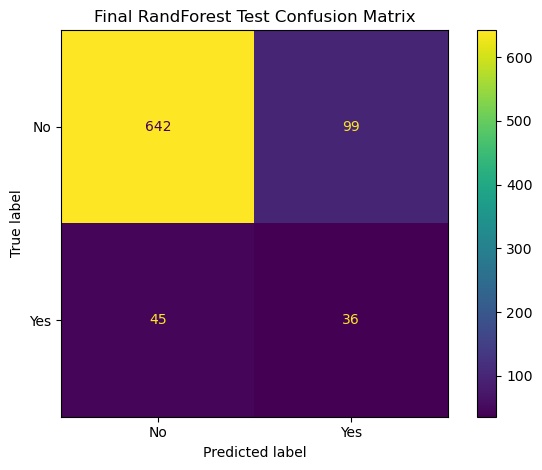

,Stage,Params,Recall,Accuracy,Precision,F1
0,Best test,"{'n_estimators': 800, 'min_samples_leaf': 1, '...",0.444,0.825,0.267,0.333
1,Val,"{'n_estimators': 800, 'min_samples_leaf': 1, '...",0.495,0.810,0.290,0.366
2,Val,"{'n_estimators': 100, 'min_samples_leaf': 1, '...",0.363,0.884,0.471,0.410
3,Val,"{'n_estimators': 100, 'min_samples_leaf': 5, '...",0.352,0.880,0.444,0.393


In [80]:
#choose the best result parameters based on Recall metric output
best_params = results1_rf.iloc[0]["Params"]
best_params

# fit the best model to the training set
rf_final = RandomForestClassifier(**best_params,random_state=rand_state,class_weight="balanced")
rf_final.fit(X_ml1_train, y_ml1_train)

#Final prediction on test
y_pred_rf = rf_final.predict(X_ml1_test)


#display confusion matrix
cm = confusion_matrix(y_ml1_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
disp.ax_.set_title("Final RandForest Test Confusion Matrix")
plt.tight_layout()
plt.show()

results1_rf.loc[-1] = {
    "Stage": "Best test",
    "Params": best_params,
    "Recall": round(recall_score(y_ml1_test, y_pred_rf), 3),
    "Accuracy": round(accuracy_score(y_ml1_test, y_pred_rf), 3),
    "Precision": round(precision_score(y_ml1_test, y_pred_rf), 3),
    "F1": round(f1_score(y_ml1_test, y_pred_rf), 3)
}

results1_rf.index = results1_rf.index + 1
results1_rf = results1_rf.sort_index()
results1_rf

##### c.3.1.3. Logistic regression

In [81]:
## Logistic Regression

# Take the random sample of the parameters I coded above using the ParameterSampler method from sklearn
random_params_lr = list(ParameterSampler(logit_param_grid,n_iter=3, random_state=rand_state))

results = []
# Do a loop through the parameter sample
for params in random_params_lr:

    # Define the model
    lr_model = LogisticRegression(**params, random_state=rand_state, class_weight="balanced")

    # Fit the model to the training set 
    lr_model.fit(X_ml1_train, y_ml1_train)

    # Predict using validation set and report Recall at validation stage
    y_pred_lr = lr_model.predict(X_ml1_val)

    # print(f"--- LogReg {params} ---")
    # cm = confusion_matrix(y_ml1_val, y_pred_lr)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    # disp.plot()
    # disp.ax_.set_title(f"{params} Val Confusion Matrix")
    # plt.tight_layout()
    # plt.show()

    results.append({
        "Stage": "Val",
         "Params": params,
         "Recall": round(recall_score(y_ml1_val, y_pred_lr),3),
         "Accuracy": round(accuracy_score(y_ml1_val, y_pred_lr),3),
         "Precision": round(precision_score(y_ml1_val, y_pred_lr),3),
         "F1": round(f1_score(y_ml1_val, y_pred_lr),3)

    })


results1_lr = pd.DataFrame(results).sort_values("Recall", ascending=False).reset_index(drop=True)
display(results1_lr)


,Stage,Params,Recall,Accuracy,Precision,F1
0,Val,"{'solver': 'liblinear', 'penalty': 'l2', 'C': 10}",0.637,0.663,0.192,0.295
1,Val,"{'solver': 'liblinear', 'penalty': 'l1', 'C': 1}",0.637,0.659,0.190,0.293
2,Val,"{'solver': 'liblinear', 'penalty': 'l2', 'C': ...",0.495,0.759,0.228,0.312


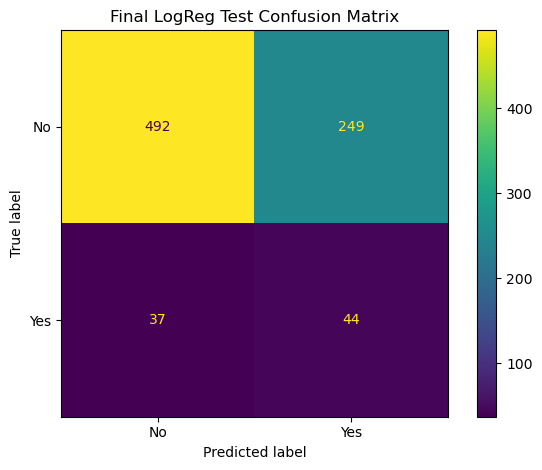

,Stage,Params,Recall,Accuracy,Precision,F1
0,Best test,"{'solver': 'liblinear', 'penalty': 'l2', 'C': 10}",0.543,0.652,0.150,0.235
1,Val,"{'solver': 'liblinear', 'penalty': 'l2', 'C': 10}",0.637,0.663,0.192,0.295
2,Val,"{'solver': 'liblinear', 'penalty': 'l1', 'C': 1}",0.637,0.659,0.190,0.293
3,Val,"{'solver': 'liblinear', 'penalty': 'l2', 'C': ...",0.495,0.759,0.228,0.312


In [82]:
#choose the best result parameters based on Recall metric output
best_params = results1_lr.iloc[0]["Params"]
best_params

# fit the best model to the training set
lr_final = LogisticRegression(**best_params,random_state=rand_state,class_weight="balanced")
lr_final.fit(X_ml1_train, y_ml1_train)

#Final prediction on test
y_pred_lr = lr_final.predict(X_ml1_test)


#display confusion matrix
cm = confusion_matrix(y_ml1_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
disp.ax_.set_title("Final LogReg Test Confusion Matrix")
plt.tight_layout()
plt.show()

results1_lr.loc[-1] = {
    "Stage": "Best test",
    "Params": best_params,
    "Recall": round(recall_score(y_ml1_test, y_pred_lr), 3),
    "Accuracy": round(accuracy_score(y_ml1_test, y_pred_lr), 3),
    "Precision": round(precision_score(y_ml1_test, y_pred_lr), 3),
    "F1": round(f1_score(y_ml1_test, y_pred_lr), 3)
}

results1_lr.index = results1_lr.index + 1
results1_lr = results1_lr.sort_index()
results1_lr

#### c.3.2. Training and validating models manually - data variation 2

##### c.3.2.1. Classification tree

In [83]:
## Classification tree

results = []
# Do a loop through the parameter sample
for params in random_params_ct:

    # Define the model
    ct_model = DecisionTreeClassifier(**params, random_state=rand_state, class_weight="balanced")

    # Fit the model to the training set 
    ct_model.fit(X_ml2_train, y_ml2_train)

    # Predict using validation set and report Recall at validation stage
    y_pred_ct = ct_model.predict(X_ml2_val)

    # print(f"--- Classification tree {params} ---")
    # cm = confusion_matrix(y_ml2_val, y_pred_ct)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    # disp.plot()
    # disp.ax_.set_title(f"{params} Val Confusion Matrix")
    # plt.tight_layout()
    # plt.show()

    results.append({
        "Stage": "Val",
         "Params": params,
         "Recall": round(recall_score(y_ml2_val, y_pred_ct),3),
         "Accuracy": round(accuracy_score(y_ml2_val, y_pred_ct),3),
         "Precision": round(precision_score(y_ml2_val, y_pred_ct),3),
         "F1": round(f1_score(y_ml2_val, y_pred_ct),3)

    })

results2_ct = pd.DataFrame(results).sort_values("Recall", ascending=False).reset_index(drop=True)
display(results2_ct)


,Stage,Params,Recall,Accuracy,Precision,F1
0,Val,"{'min_samples_split': 50, 'max_depth': 6, 'ccp...",0.592,0.654,0.178,0.274
1,Val,"{'min_samples_split': 50, 'max_depth': 5, 'ccp...",0.394,0.758,0.199,0.264
2,Val,"{'min_samples_split': 5, 'max_depth': 3, 'ccp_...",0.310,0.891,0.512,0.386


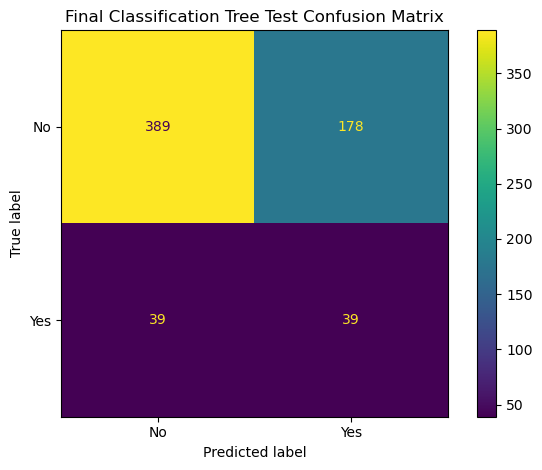

,Stage,Params,Recall,Accuracy,Precision,F1
0,Best test,"{'min_samples_split': 50, 'max_depth': 6, 'ccp...",0.500,0.664,0.180,0.264
1,Val,"{'min_samples_split': 50, 'max_depth': 6, 'ccp...",0.592,0.654,0.178,0.274
2,Val,"{'min_samples_split': 50, 'max_depth': 5, 'ccp...",0.394,0.758,0.199,0.264
3,Val,"{'min_samples_split': 5, 'max_depth': 3, 'ccp_...",0.310,0.891,0.512,0.386


In [84]:
#choose the best result parameters based on Recall metric output
best_params = results2_ct.iloc[0]["Params"]
best_params

# fit the best model to the training set
ct_final = DecisionTreeClassifier(**best_params,random_state=rand_state,class_weight="balanced")
ct_final.fit(X_ml2_train, y_ml2_train)

#Final prediction on test
y_pred_ct = ct_final.predict(X_ml2_test)


#display confusion matrix
cm = confusion_matrix(y_ml2_test, y_pred_ct)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
disp.ax_.set_title("Final Classification Tree Test Confusion Matrix")
plt.tight_layout()
plt.show()

results2_ct.loc[-1] = {
    "Stage": "Best test",
    "Params": best_params,
    "Recall": round(recall_score(y_ml2_test, y_pred_ct), 3),
    "Accuracy": round(accuracy_score(y_ml2_test, y_pred_ct), 3),
    "Precision": round(precision_score(y_ml2_test, y_pred_ct), 3),
    "F1": round(f1_score(y_ml2_test, y_pred_ct), 3)
}

results2_ct.index = results2_ct.index + 1
results2_ct = results2_ct.sort_index()
results2_ct

#### c.3.2.2. Random forests

In [85]:
## Random forests

results = []
# Do a loop through the parameter sample
for params in random_params_rf:

    # Define the model
    rf_model = RandomForestClassifier(**params, random_state=rand_state, class_weight="balanced")

    # Fit the model to the training set 
    rf_model.fit(X_ml2_train, y_ml2_train)

    # Predict using validation set and report Recall at validation stage
    y_pred_rf = rf_model.predict(X_ml2_val)

    # print(f"--- Random forest {params} ---")
    # cm = confusion_matrix(y_ml2_val, y_pred_rf)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    # disp.plot()
    # disp.ax_.set_title(f"{params} Val Confusion Matrix")
    # plt.tight_layout()
    # plt.show()

    results.append({
        "Stage": "Val",
         "Params": params,
         "Recall": round(recall_score(y_ml2_val, y_pred_rf),3),
         "Accuracy": round(accuracy_score(y_ml2_val, y_pred_rf),3),
         "Precision": round(precision_score(y_ml2_val, y_pred_rf),3),
         "F1": round(f1_score(y_ml2_val, y_pred_rf),3)

    })


results2_rf = pd.DataFrame(results).sort_values("Recall", ascending=False).reset_index(drop=True)
display(results2_rf)


,Stage,Params,Recall,Accuracy,Precision,F1
0,Val,"{'n_estimators': 800, 'min_samples_leaf': 1, '...",0.423,0.812,0.273,0.331
1,Val,"{'n_estimators': 100, 'min_samples_leaf': 5, '...",0.394,0.840,0.318,0.352
2,Val,"{'n_estimators': 100, 'min_samples_leaf': 1, '...",0.352,0.843,0.312,0.331


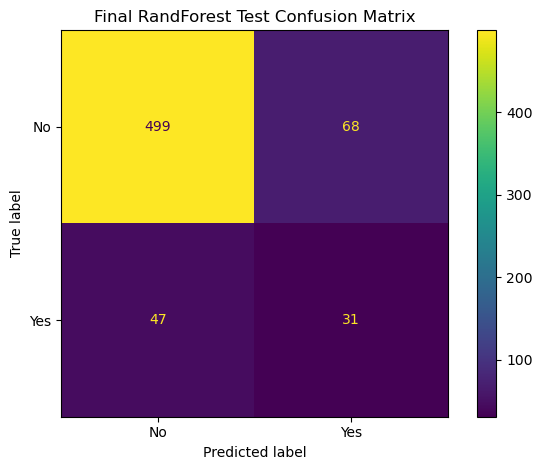

,Stage,Params,Recall,Accuracy,Precision,F1
0,Best test,"{'n_estimators': 800, 'min_samples_leaf': 1, '...",0.397,0.822,0.313,0.350
1,Val,"{'n_estimators': 800, 'min_samples_leaf': 1, '...",0.423,0.812,0.273,0.331
2,Val,"{'n_estimators': 100, 'min_samples_leaf': 5, '...",0.394,0.840,0.318,0.352
3,Val,"{'n_estimators': 100, 'min_samples_leaf': 1, '...",0.352,0.843,0.312,0.331


In [86]:
#choose the best result parameters based on Recall metric output
best_params = results2_rf.iloc[0]["Params"]
best_params

# fit the best model to the training set
rf_final = RandomForestClassifier(**best_params,random_state=rand_state,class_weight="balanced")
rf_final.fit(X_ml2_train, y_ml2_train)

#Final prediction on test
y_pred_rf = rf_final.predict(X_ml2_test)


#display confusion matrix
cm = confusion_matrix(y_ml2_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
disp.ax_.set_title("Final RandForest Test Confusion Matrix")
plt.tight_layout()
plt.show()

results2_rf.loc[-1] = {
    "Stage": "Best test",
    "Params": best_params,
    "Recall": round(recall_score(y_ml2_test, y_pred_rf), 3),
    "Accuracy": round(accuracy_score(y_ml2_test, y_pred_rf), 3),
    "Precision": round(precision_score(y_ml2_test, y_pred_rf), 3),
    "F1": round(f1_score(y_ml2_test, y_pred_rf), 3)
}

results2_rf.index = results2_rf.index + 1
results2_rf = results2_rf.sort_index()
results2_rf

#### c.3.2.3. Logistic regression

In [87]:
## Logistic Regression

results = []
# Do a loop through the parameter sample
for params in random_params_lr:

    # Define the model
    lr_model = LogisticRegression(**params, random_state=rand_state, class_weight="balanced")

    # Fit the model to the training set 
    lr_model.fit(X_ml2_train, y_ml2_train)

    # Predict using validation set and report Recall at validation stage
    y_pred_lr = lr_model.predict(X_ml2_val)

    # print(f"--- LogReg {params} ---")
    # cm = confusion_matrix(y_ml2_val, y_pred_lr)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    # disp.plot()
    # disp.ax_.set_title(f"{params} Val Confusion Matrix")
    # plt.tight_layout()
    # plt.show()

    results.append({
        "Stage": "Val",
         "Params": params,
         "Recall": round(recall_score(y_ml2_val, y_pred_lr),3),
         "Accuracy": round(accuracy_score(y_ml2_val, y_pred_lr),3),
         "Precision": round(precision_score(y_ml2_val, y_pred_lr),3),
         "F1": round(f1_score(y_ml2_val, y_pred_lr),3)

    })


results2_lr = pd.DataFrame(results).sort_values("Recall", ascending=False).reset_index(drop=True)
display(results2_lr)

,Stage,Params,Recall,Accuracy,Precision,F1
0,Val,"{'solver': 'liblinear', 'penalty': 'l2', 'C': 10}",0.577,0.682,0.190,0.286
1,Val,"{'solver': 'liblinear', 'penalty': 'l1', 'C': 1}",0.577,0.684,0.191,0.287
2,Val,"{'solver': 'liblinear', 'penalty': 'l2', 'C': ...",0.423,0.816,0.278,0.335


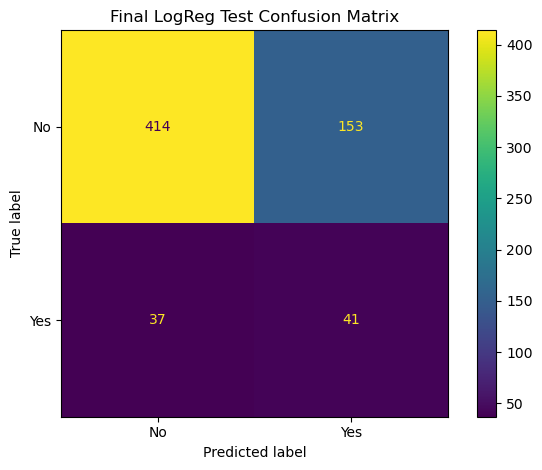

,Stage,Params,Recall,Accuracy,Precision,F1
0,Best test,"{'solver': 'liblinear', 'penalty': 'l2', 'C': 10}",0.526,0.705,0.211,0.301
1,Val,"{'solver': 'liblinear', 'penalty': 'l2', 'C': 10}",0.577,0.682,0.190,0.286
2,Val,"{'solver': 'liblinear', 'penalty': 'l1', 'C': 1}",0.577,0.684,0.191,0.287
3,Val,"{'solver': 'liblinear', 'penalty': 'l2', 'C': ...",0.423,0.816,0.278,0.335


In [88]:
#choose the best result parameters based on Recall metric output
best_params = results2_lr.iloc[0]["Params"]
best_params

# fit the best model to the training set
lr_final = LogisticRegression(**best_params,random_state=rand_state,class_weight="balanced")
lr_final.fit(X_ml2_train, y_ml2_train)

#Final prediction on test
y_pred_lr = lr_final.predict(X_ml2_test)

#display confusion matrix
cm = confusion_matrix(y_ml2_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()
disp.ax_.set_title("Final LogReg Test Confusion Matrix")
plt.tight_layout()
plt.show()

results2_lr.loc[-1] = {
    "Stage": "Best test",
    "Params": best_params,
    "Recall": round(recall_score(y_ml2_test, y_pred_lr), 3),
    "Accuracy": round(accuracy_score(y_ml2_test, y_pred_lr), 3),
    "Precision": round(precision_score(y_ml2_test, y_pred_lr), 3),
    "F1": round(f1_score(y_ml2_test, y_pred_lr), 3)
}

results2_lr.index = results2_lr.index + 1
results2_lr = results2_lr.sort_index()
results2_lr

#### d)

##### d.1. Cross-Validation Grid Search

#### e)